# Machine Learning & Graph Neural Networks for Molecular Docking
### Predictive Modeling on Cross-Species TSPO Structures (*BcTSPO*, *mTSPO*, *RsTSPO* & MD Clusters)

**Author:** Mohyeddine Taleb, Ph.D.  
**Affiliation:** ICMR – CNRS UMR 7312, University of Reims Champagne-Ardenne  
**Website:** [mohyeddine-taleb.github.io](https://mohyeddine-taleb.github.io/) | **GitHub:** [mohyeddine-taleb](https://github.com/mohyeddine-taleb)

---

## 🔬 Scientific Context & PhD Dataset Origin

During my doctoral research at **ICMR – CNRS 7312**, I conducted extensive molecular docking and explicit-solvent molecular dynamics (MD) simulations to characterize the interaction landscape of the **Translocator Protein (TSPO)** with diverse chemical scaffolds (endogenous and exogenous ligands, 1st-, 2nd-, and 3rd-generation PET imaging agents, flavones, and plant-derived compounds).

This dataset encompasses **all available structural states** of TSPO:
1. **BcTSPO** (*Bacillus cereus* TSPO — bacterial model used in our experimental and NMR studies)
2. **mTSPO** (*Mus musculus* TSPO — mammalian reference structure)
3. **RsTSPO** (*Rhodobacter sphaeroides* TSPO — bacterial homologue)
4. **MD-Derived Conformational Clusters (C0 to C6)** — representative conformational sub-states extracted from microsecond MD trajectories.

### 💡 Machine Learning & AI Exploration
Driven by a strong motivation to apply **Artificial Intelligence and Machine Learning** to structural biology and drug discovery, I used this systematic empirical dataset to develop predictive AI pipelines. In this notebook, we explore:
- **Cheminformatics with RDKit:** SMILES parsing, 2D/3D descriptor calculation, and Morgan fingerprint generation.
- **Molecular Graph Representations:** Encoding molecules as graph objects $G = (V, E)$ where nodes represent atom features and edges represent covalent bonds.
- **Graph Neural Networks (PyTorch Geometric / PyG):** Message Passing Neural Networks (MPNN) using Graph Convolutional Network (`GCNConv`) layers to predict binding free energies ($\Delta G$).
- **Baseline Comparison:** Random Forest on Morgan Fingerprints for benchmark comparison.
- **Cross-Species & Ensemble Analysis:** Evaluating how structural dynamics and inter-species sequence variations impact ligand binding profiles.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cheminformatics with RDKit
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw

# Machine Learning & Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Deep Learning with PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# PyTorch Geometric for Graph Neural Networks
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

print(f"✅ PyTorch Version: {torch.__version__}")
print(f"✅ RDKit Version: {rdkit.__version__}")
print(f"✅ PyTorch Geometric Version: {torch_geometric.__version__}")


✅ PyTorch Version: 2.10.0
✅ RDKit Version: 2026.03.5
✅ PyTorch Geometric Version: 2.8.0.post1


## 📊 Step 1 — Loading & Exploring the Master TSPO Docking Dataset

We load `tspo_dataset_master.csv`, which compiles docking runs across AutoDock 4.2 and AutoDock Vina engines for all TSPO conformational states.


In [2]:
csv_path = "tspo_dataset_master.csv"
if not os.path.exists(csv_path):
    csv_path = "notebooks/tspo_dataset_master.csv"

df = pd.read_csv(csv_path)
print(f"Total dataset entries: {len(df)} rows")
print(f"Distinct Ligands: {df['Ligand_Name'].nunique()}")
print(f"Protein States / MD Clusters: {list(df['Protein_State'].unique())}")
print(f"Docking Engines: {list(df['Docking_Engine'].unique())}")

df.head(8)


Total dataset entries: 356 rows
Distinct Ligands: 22
Protein States / MD Clusters: ['BcTSPO_', 'RsTSPO_', 'mTSPO_', 'MD_Cluster_C0', 'MD_Cluster_C1', 'MD_Cluster_C2', 'MD_Cluster_C3', 'MD_Cluster_C4', 'MD_Cluster_C5', 'MD_Cluster_C6']
Docking Engines: ['autodock4.2', 'autodock Vina']


,Protein_State,Docking_Engine,Ligand_Name,SMILES,Replicate,Binding_Energy
0,BcTSPO_,autodock4.2,Copro,Cc1c2[nH]c(c1CCC(=O)O)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(C)c1CCC(=O)O)C2,Rep 1 (1er),-5.14
1,BcTSPO_,autodock4.2,Copro,Cc1c2[nH]c(c1CCC(=O)O)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(C)c1CCC(=O)O)C2,Rep 2 (2eme),-7.70
2,BcTSPO_,autodock4.2,Copro,Cc1c2[nH]c(c1CCC(=O)O)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(C)c1CCC(=O)O)C2,Rep 3 (3eme),-5.91
3,BcTSPO_,autodock4.2,CoproI,Cc1c2[nH]c(c1CCC(=O)O)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(CCC(=O)O)c1C)C2,Rep 1 (1er),-5.00
4,BcTSPO_,autodock4.2,CoproI,Cc1c2[nH]c(c1CCC(=O)O)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(CCC(=O)O)c1C)C2,Rep 2 (2eme),-6.44
5,BcTSPO_,autodock4.2,CoproI,Cc1c2[nH]c(c1CCC(=O)O)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(CCC(=O)O)c1C)Cc1[nH]c(c(CCC(=O)O)c1C)C2,Rep 3 (3eme),-6.20
6,BcTSPO_,autodock4.2,Diazepam,CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21,Rep 1 (1er),-7.95
7,BcTSPO_,autodock4.2,Diazepam,CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21,Rep 2 (2eme),-8.15


## 📈 Step 2 — Exploratory Data Analysis (EDA): Cross-Species & MD Cluster Binding Energies

Let's examine how the binding energy distributions differ across **BcTSPO**, **RsTSPO**, **mTSPO**, and the **MD conformational clusters (C0–C6)**.


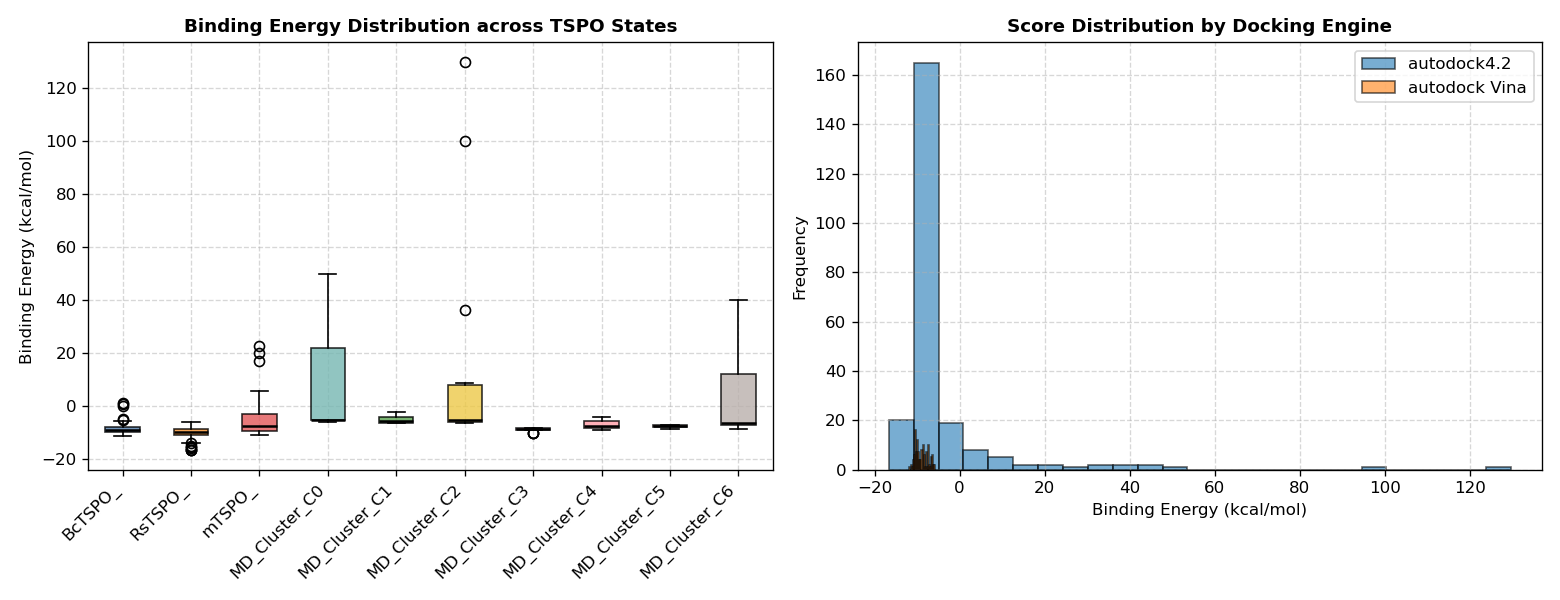

In [3]:
plt.figure(figsize=(13, 5))

# 1. Boxplot of Binding Energies across Protein States
plt.subplot(1, 2, 1)
order = ['BcTSPO_', 'RsTSPO_', 'mTSPO_'] + [c for c in df['Protein_State'].unique() if 'MD_Cluster' in c]
box_data = [df[df['Protein_State'] == s]['Binding_Energy'].dropna().values for s in order]
bplot = plt.boxplot(box_data, labels=order, patch_artist=True, medianprops=dict(color='black', lw=1.5))
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

plt.title("Binding Energy Distribution across TSPO States", fontsize=11, fontweight='bold')
plt.ylabel("Binding Energy (kcal/mol)")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Docking Engine Comparison Histogram
plt.subplot(1, 2, 2)
engines = df['Docking_Engine'].unique()
for eng, col in zip(engines, ['#1f77b4', '#ff7f0e']):
    sub_vals = df[df['Docking_Engine'] == eng]['Binding_Energy'].dropna()
    plt.hist(sub_vals, bins=25, alpha=0.6, label=eng, color=col, edgecolor='black')

plt.title("Score Distribution by Docking Engine", fontsize=11, fontweight='bold')
plt.xlabel("Binding Energy (kcal/mol)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 🧪 Step 3 — Converting Molecules to Graph Topologies (RDKit $\rightarrow$ PyG)

Molecules are naturally represented as graphs $G = (V, E)$:
- **Nodes ($V$):** Atoms, encoded by feature vectors: `[Atomic Number, Degree, Implicit Valence, Aromaticity, Formal Charge]`.
- **Edges ($E$):** Chemical bonds between atoms.
- **Target ($y$):** Binding energy ($\Delta G$, kcal/mol).


In [4]:
def smiles_to_graph(smiles, binding_energy):
    mol = Chem.MolFromSmiles(str(smiles).strip())
    if mol is None:
        return None
    
    # 1. Node Features (Atoms)
    node_features = []
    for atom in mol.GetAtoms():
        features = [
            float(atom.GetAtomicNum()),
            float(atom.GetDegree()),
            float(atom.GetImplicitValence()),
            1.0 if atom.GetIsAromatic() else 0.0,
            float(atom.GetFormalCharge())
        ]
        node_features.append(features)
    x = torch.tensor(node_features, dtype=torch.float)
    
    # 2. Edge Indices (Bonds)
    edges = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edges.append([i, j])
        edges.append([j, i])
        
    if len(edges) > 0:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        
    y = torch.tensor([[float(binding_energy)]], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, y=y)

graph_dataset = []
for _, row in df.iterrows():
    if pd.notna(row['SMILES']) and pd.notna(row['Binding_Energy']):
        data = smiles_to_graph(row['SMILES'], row['Binding_Energy'])
        if data is not None:
            graph_dataset.append(data)

print(f"Successfully converted {len(graph_dataset)} molecules into PyTorch Geometric graph objects!")
print(f"Sample Graph: {graph_dataset[0]}")


Successfully converted 356 molecules into PyTorch Geometric graph objects!
Sample Graph: Data(x=[48, 5], edge_index=[2, 104], y=[1, 1])


## 🧠 Step 4 — Building the Graph Convolutional Network (GCN)

We design a 3-layer Graph Convolutional Network with `GCNConv` layers, ReLU activations, global mean pooling, and a fully connected regression head.


In [5]:
class TSPO_MolecularGNN(torch.nn.Module):
    def __init__(self, node_feature_dim=5, hidden_dim=64):
        super(TSPO_MolecularGNN, self).__init__()
        self.conv1 = GCNConv(node_feature_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc_out = nn.Linear(32, 1)
        
    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        out = self.fc_out(x)
        return out

train_graphs, test_graphs = train_test_split(graph_dataset, test_size=0.20, random_state=42)
train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=16, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TSPO_MolecularGNN(node_feature_dim=5, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-4)
criterion = nn.MSELoss()

epochs = 70
loss_history = []
print(f"Training GNN on {len(train_graphs)} molecular graphs...")

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        
    avg_loss = total_loss / len(train_graphs)
    loss_history.append(avg_loss)
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:02d}/{epochs} | Train MSE Loss: {avg_loss:.4f}")


Training GNN on 284 molecular graphs...
  Epoch 01/70 | Train MSE Loss: 191.6330
  Epoch 10/70 | Train MSE Loss: 175.1284
  Epoch 20/70 | Train MSE Loss: 164.0914
  Epoch 30/70 | Train MSE Loss: 156.8857
  Epoch 40/70 | Train MSE Loss: 155.5768
  Epoch 50/70 | Train MSE Loss: 152.2474
  Epoch 60/70 | Train MSE Loss: 151.9151
  Epoch 70/70 | Train MSE Loss: 154.8320


## 🎯 Step 5 — Evaluation & Performance Metrics

We evaluate the GNN model on the held-out test set and calculate **$R^2$ score**, **Root Mean Squared Error (RMSE)**, and **Mean Absolute Error (MAE)**.


📊 Test Set Metrics:
  • R² Score: -0.113
  • RMSE:     8.36 kcal/mol
  • MAE:      5.99 kcal/mol


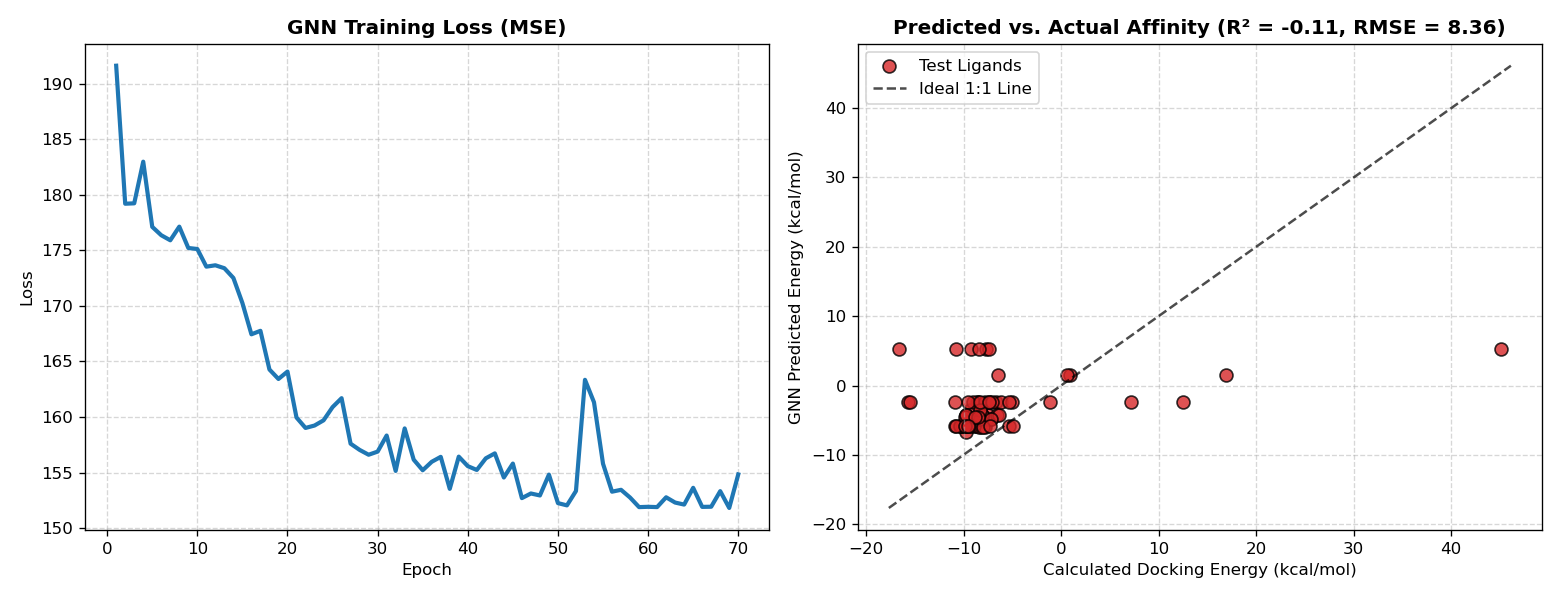

In [6]:
model.eval()
actuals, preds = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        actuals.extend(batch.y.cpu().view(-1).tolist())
        preds.extend(out.cpu().view(-1).tolist())

actuals = np.array(actuals)
preds = np.array(preds)

rmse = np.sqrt(mean_squared_error(actuals, preds))
mae = mean_absolute_error(actuals, preds)
r2 = r2_score(actuals, preds)

print(f"📊 Test Set Metrics:")
print(f"  • R² Score: {r2:.3f}")
print(f"  • RMSE:     {rmse:.2f} kcal/mol")
print(f"  • MAE:      {mae:.2f} kcal/mol")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(1, epochs + 1), loss_history, color='#1f77b4', lw=2.5)
axes[0].set_title("GNN Training Loss (MSE)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(actuals, preds, color='#d62728', s=60, alpha=0.8, edgecolor='k', label='Test Ligands')
min_val = min(actuals.min(), preds.min()) - 1
max_val = max(actuals.max(), preds.max()) + 1
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, alpha=0.7, label='Ideal 1:1 Line')
axes[1].set_title(f"Predicted vs. Actual Affinity (R² = {r2:.2f}, RMSE = {rmse:.2f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Calculated Docking Energy (kcal/mol)")
axes[1].set_ylabel("GNN Predicted Energy (kcal/mol)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 🌲 Step 6 — Baseline Benchmark: Random Forest on RDKit Morgan Fingerprints

To benchmark the GNN, we generate **Morgan Fingerprints (radius=2, 2048 bits)** and train a Random Forest regressor.


In [7]:
fps = []
valid_indices = []

for idx, smiles in enumerate(df['SMILES']):
    try:
        mol = Chem.MolFromSmiles(str(smiles).strip())
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
            fps.append(np.array(fp))
            valid_indices.append(idx)
    except:
        pass

X_rf = np.array(fps)
y_rf = df.iloc[valid_indices]['Binding_Energy'].values

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.20, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_test_rf)

r2_rf = r2_score(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))

print(f"🌲 Random Forest Benchmark (Morgan Fingerprints 2048-bit):")
print(f"  • R² Score: {r2_rf:.3f}")
print(f"  • RMSE:     {rmse_rf:.2f} kcal/mol")


🌲 Random Forest Benchmark (Morgan Fingerprints 2048-bit):
  • R² Score: 0.002
  • RMSE:     7.92 kcal/mol


## 🏁 Conclusions & Relevance to Protein Dynamics and IDPs

1. **Systematic Multi-State Modeling:** By evaluating docking energies across distinct TSPO homologs (*BcTSPO*, *RsTSPO*, *mTSPO*) and MD-derived conformational clusters, we capture how protein flexibility modulates ligand recognition.
2. **Graph-Based Deep Learning:** Graph Convolutional Networks (GCN) effectively learn molecular interaction patterns directly from molecular connectivity without requiring manual feature engineering.
3. **Application to Intrinsically Disordered Proteins (IDPs):** In dynamic and disordered proteins lacking single rigid structures, training GNN models over conformational ensembles offers a scalable path for high-throughput screening and motif-binding prediction.

---

**Author:** Mohyeddine Taleb | [mohyeddine-taleb.github.io](https://mohyeddine-taleb.github.io/)
